In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import os
import nibabel as nib
import logging
import mri_utils
import utils

# torch.set_num_threads(24) # Anzahl deiner zugewiesenen Kerne
# torch.set_num_interop_threads(24)
print(torch.cuda.is_available())

True


In [2]:
# Hyperparameter
AMOUNT_VOLUMES_TO_LOAD = 1
PATCH_SIZE = (32, 32, 31)
RUN_WITH_TRAINING = False
SAVE_MODEL = False
OVERLAP = 0.5

## Import Datasets, Add Degraded and Ground Truth

In [3]:
# Funktion zum Laden und Degradieren eines Volumes
def process_volume(file_path):
    img = nib.load(file_path)

    volume = np.asanyarray(img.dataobj, dtype=np.float32)
    print(f"Loaded volume shape: {volume.shape}")

    # Degraded-Daten erstellen
    gt_vol, degraded_vol = mri_utils.generate_dataset_list(
        [volume],
        keep_fraction=0.6,
        noise_min=0.01,
        noise_max=0.05
    )

    return gt_vol[0], degraded_vol[0]

In [4]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm 
import tracemalloc

tracemalloc.start()  # Tracke RAM-Nutzung

# Konfiguration
data_folder = "/srv/fMRI-data/"
output_dir = "./processed_data"  # Verzeichnis für zwischengespeicherte Daten
os.makedirs(output_dir, exist_ok=True)


# Liste aller NIfTI-Dateien
nii_files = sorted([
    f for f in os.listdir(data_folder)
    if f.endswith(".nii.gz")
])

print(f"Found {len(nii_files)} NIfTI files in {data_folder}")

# Optional: Nur die ersten 5 Volumes verarbeiten, um die Funktion zu testen
nii_files = nii_files[:AMOUNT_VOLUMES_TO_LOAD]  


# Daten als NumPy-Arrays speichern (oder direkt verarbeiten)
gt : list[np.ndarray] = []
degraded : list[np.ndarray] = []

for file in tqdm(nii_files, desc="Processing files"):
    file_path = os.path.join(data_folder, file)

    # Volume laden und GT sowie degraded Daten erstellen
    gt_vol, degraded_vol = process_volume(file_path)
    gt.append(gt_vol)
    degraded.append(degraded_vol)

print("Daten erfolgreich verarbeitet und gespeichert.")

print(type(gt))
print(type(degraded))



utils.show_ram_usage()

Found 28 NIfTI files in /srv/fMRI-data/


Processing files:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded volume shape: (128, 128, 93, 219)
Processing volume 1/1


Processing files: 100%|██████████| 1/1 [00:30<00:00, 30.12s/it]


Dataset generation complete.
Daten erfolgreich verarbeitet und gespeichert.
<class 'list'>
<class 'list'>

                                              RAM-NUTZUNG: Speicherstatus                                               
Zeitstempel: 2026-06-19 14:12:51
------------------------------------------------------------------------------------------------------------------------
System-Prozess-Speicher (RSS): 3001.58 MiB
PyTorch CPU-Speicher: 0.00 MiB
PyTorch GPU-Speicher: 0.00 MiB
Python-Objekte (tracemalloc): 2546.78 MiB
PyTorch-Tensoren: 0.00 MiB (0 Tensoren)
GESAMT (RSS): 3001.58 MiB
------------------------------------------------------------------------------------------------------------------------



/home/schmitt/.venv/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


{'timestamp': '2026-06-19 14:12:51',
 'rss_mb': 3001.578125,
 'cpu_mem_mb': 0.0,
 'gpu_mem_mb': 0.0,
 'py_mem_mb': 2546.7840938568115,
 'tensor_mem_mb': 0.0,
 'tensor_count': 0}

## Erstelle Chunks

In [5]:
def generate_flexible_patch_coordinates(volume_shape, patch_size, overlap_factor=0.5):
    """
    Generiert Patch-Koordinaten mit einem prozentualen Overlap (z.B. 0.5 für 50%).
    Garantiert, dass auch die Ränder (Edges) vollständig abgedeckt werden, indem am Rand etwas mehr Überlappung genutzt wird, anstatt Voxels auszuschließen.
    """
    x_dim, y_dim, z_dim = volume_shape
    x_patch, y_patch, z_patch = patch_size
    
    # Berechne den Stride dynamisch basierend auf dem gewünschten Overlap
    x_stride = max(1, int(x_patch * (1 - overlap_factor))) # 16 
    y_stride = max(1, int(y_patch * (1 - overlap_factor))) # 16 
    z_stride = max(1, int(z_patch * (1 - overlap_factor))) # 15
    
    # Generiere die Startpunkte und Endpunkte als Tupel
    def get_1d_coordinates(dim_size, patch_size, stride):
        starts = list(range(0, dim_size - patch_size + 1, stride))
        
        # WICHTIG: Wenn der letzte Patch nicht exakt am Rand aufhört,
        # füge manuell einen Patch hinzu, der exakt am Rand endet.
        if (dim_size - patch_size) not in starts:
            starts.append(dim_size - patch_size)
            
        return [(start, start + patch_size) for start in starts]

    # Start & Endpunkte für jede Achse berechnen
    x_coords = get_1d_coordinates(x_dim, x_patch, x_stride)
    y_coords = get_1d_coordinates(y_dim, y_patch, y_stride)
    z_coords = get_1d_coordinates(z_dim, z_patch, z_stride)
    
    # Alle Kombinationen (3D-Gitter) zusammenbauen
    coords = []
    for x_start, x_end in x_coords:
        for y_start, y_end in y_coords:
            for z_start, z_end in z_coords:
                coords.append(((x_start, x_end), (y_start, y_end), (z_start, z_end)))
                
    return coords

In [6]:
"""
Iteriere über alle Volumes und Zeitschritte
Generiere 3D Patch-Koordinaten und speichere sie mit Volume- und Timestep-Info:
"""
print("Anzahl Volumes (gt):", len(gt))
coords = []

for volume_idx, volume in enumerate(gt):
    
    # OPTIMIERUNG: Da die räumliche Form (X, Y, Z) für alle Zeitschritte dieses 
    # Volumes gleich bleibt, berechnen wir die Basis-Koordinaten nur EINMAL pro Volume.
    coords_per_volume = generate_flexible_patch_coordinates(volume.shape[:3], PATCH_SIZE, overlap_factor=OVERLAP)
    
    timesteps = volume.shape[3]
    for t in range(timesteps):
        # Jetzt verknüpfen wir die berechneten 3D-Koordinaten mit dem aktuellen Zeitschritt
        # Eigentlich nur Anhängen des Volumes und des Timesteps an Koordinaten
        for (x_start, x_end), (y_start, y_end), (z_start, z_end) in coords_per_volume:
            coords.append([
                volume_idx, t, 
                x_start, x_end, 
                y_start, y_end, 
                z_start, z_end
            ])

# Konvertierung in ein performantes NumPy-Array
coords = np.array(coords, dtype=np.int32)

print("Finale Array-Form:", coords.shape) 
print("Beispiel-Koordinaten:")
print("Volume Idx, Timestep, X Start, X End, Y Start, Y End, Z Start, Z End:")


print("Erster Patch:", coords[0])
print("Letzter Patch:", coords[-1])

# Ohne Überlappung
# 1. Volume => 10512 Patches
# 10512 => 48 (Anzahl Patches per Bild: 4*4*3) * 219 timesteps
# Patches pro Bild: 128 / 32= 4 für X und Y, 93 / 31 = 3 für Z

# Durch Überlappung kommt es zu Versechsfachung der Patches. Patches pro Timestep jetzt 294 (7*7*6)
# 294 Patches pro Bild * 219 Timesteps => 64_386


Anzahl Volumes (gt): 1
Finale Array-Form: (64386, 8)
Beispiel-Koordinaten:
Volume Idx, Timestep, X Start, X End, Y Start, Y End, Z Start, Z End:
Erster Patch: [ 0  0  0 32  0 32  0 31]
Letzter Patch: [  0 218  96 128  96 128  62  93]


### Visualize same Ground Truth and Degraded image

Volume GT shape: (128, 128, 93, 219)
Volume DG shape: (128, 128, 93, 219)


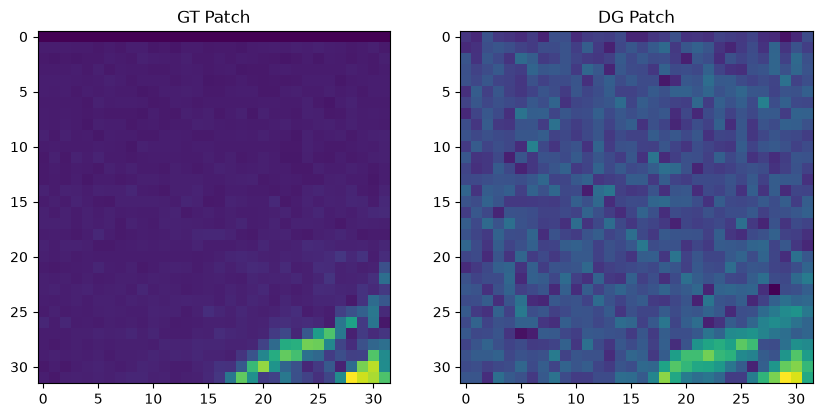

In [7]:
# Visualisiere erstes volumes, erster patch
first_coords = coords[0]  # Koordinaten des ersten Volumes
Volume_Idx, Timestep, X_Start, X_End, Y_Start, Y_End, Z_Start, Z_End = first_coords

volume_gt = gt[Volume_Idx]
volume_dg = degraded[Volume_Idx]

print("Volume GT shape:", volume_gt.shape)
print("Volume DG shape:", volume_dg.shape)

# display volume from with width, heigth, 0 for 2d image and timestep
image_gt = volume_gt[X_Start:X_End, Y_Start:Y_End, 0, Timestep]
image_dg = volume_dg[X_Start:X_End, Y_Start:Y_End, 0, Timestep]


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_gt)
plt.title("GT Patch")

plt.subplot(1,2,2)
plt.imshow(image_dg)
plt.title("DG Patch")

plt.show()

### Normalisierung

In [8]:
def precompute_volume_stats(degraded_volumes, bg_threshold=10.0):
    """
    Berechnet Mittelwert und Standardabweichung für jedes Volumen und Timestep basierend auf einem Schwellwert für Hintergrundrauschen.
    Die Statistiken werden für die Normalisierung der Daten vor dem Training verwendet.
    """
    volume_stats = {}
    
    for vol_idx, deg_volume in enumerate(degraded_volumes):
        volume_stats[vol_idx] = {}
        num_timesteps = deg_volume.shape[-1]
        
        for t in range(num_timesteps):
            vol_3d = deg_volume[..., t]
            brain_mask = vol_3d > bg_threshold
            
            if np.sum(brain_mask) > 0:
                mean_val = float(np.mean(vol_3d[brain_mask]))
                std_val = float(np.std(vol_3d[brain_mask])) + 1e-8
            else:
                mean_val = float(np.mean(vol_3d))
                std_val = float(np.std(vol_3d)) + 1e-8
            
            volume_stats[vol_idx][t] = (mean_val, std_val)
            
    return volume_stats


calculated_stats = precompute_volume_stats(degraded, bg_threshold=10.0)
print(len(calculated_stats))

1


### Dataset

In [9]:

class VolumeDataset(Dataset):
    def __init__(self, degraded_volumes, gt_volumes, coords, volume_stats):
        """
        Args:
            degraded_volumes: Liste/Array der degradierten fMRI-Daten (Input).
                              Erwartete Form pro Element: [X, Y, Z, Timesteps]
            gt_volumes:       Liste/Array der Ground-Truth-Daten (Target).
            coords:           NumPy-Array mit den Koordinaten (Gesamtanzahl_Patches, 8).
            bg_threshold:     Schwellenwert, um den dunklen Hintergrund von der 
                              Normalisierung auszuschließen.
        """
        assert len(degraded_volumes) == len(gt_volumes), "Anzahl der degraded und gt Volumes muss gleich sein!"
        
        self.degraded_volumes = degraded_volumes
        self.gt_volumes = gt_volumes
        self.coords = coords
        self.volume_stats = volume_stats

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        # 1. Koordinaten auslesen
        coord = self.coords[idx]
        volume_idx, timestep, x_start, x_end, y_start, y_end, z_start, z_end = coord
        
        # 2. Volumes holen
        deg_volume = self.degraded_volumes[volume_idx]
        gt_volume  = self.gt_volumes[volume_idx]

        # 3. Patch erstellen
        patch_deg = deg_volume[x_start:x_end, y_start:y_end, z_start:z_end, timestep]
        patch_gt  = gt_volume[x_start:x_end, y_start:y_end, z_start:z_end, timestep]

        # 4. In PyTorch-Tensoren umwandeln (1, X, Y, Z)
        tensor_deg = torch.tensor(patch_deg, dtype=torch.float32).unsqueeze(0)
        tensor_gt  = torch.tensor(patch_gt, dtype=torch.float32).unsqueeze(0)

        # Statistiken heraussuchen (O(1) Komplexität, extrem schnell)
        mean_vol, std_vol = self.volume_stats[volume_idx][timestep]

        # 6. Normalisierung mit den 3D-Volume-Werten
        tensor_deg = (tensor_deg - mean_vol) / std_vol
        tensor_gt  = (tensor_gt - mean_vol) / std_vol  # Wichtig: Gleiche Werte für das Target!

        return tensor_deg, tensor_gt, coord, mean_vol, std_vol

### Dataset + Dataloader

In [10]:
dataset = VolumeDataset(degraded, gt, coords, calculated_stats)
print(f"Gesamtanzahl Patches im Dataset: {len(dataset)}")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# TODO: EIn Batch könnte nach wie vor Daten aus mehr als einem Volume/Timestep haben, -> Recherche dazu. Obwohl Batch Size von 32 erstmal vernünftig sein könnte
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)

# Use seperate dataloader to generate predictions. On whole dataset
val_dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# garbage collector
import gc
gc.collect()

utils.show_ram_usage()

Gesamtanzahl Patches im Dataset: 64386
Train size: 51508, Test size: 12878

                                              RAM-NUTZUNG: Speicherstatus                                               
Zeitstempel: 2026-06-19 14:12:56
------------------------------------------------------------------------------------------------------------------------
System-Prozess-Speicher (RSS): 3031.66 MiB
PyTorch CPU-Speicher: 0.00 MiB
PyTorch GPU-Speicher: 0.00 MiB
Python-Objekte (tracemalloc): 5.25 MiB
PyTorch-Tensoren: 0.00 MiB (0 Tensoren)
GESAMT (RSS): 3031.66 MiB
------------------------------------------------------------------------------------------------------------------------


{'timestamp': '2026-06-19 14:12:56',
 'rss_mb': 3031.6640625,
 'cpu_mem_mb': 0.0,
 'gpu_mem_mb': 0.0,
 'py_mem_mb': 5.2495269775390625,
 'tensor_mem_mb': 0.0,
 'tensor_count': 0}

###  3D CNN

In [11]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.bn = nn.BatchNorm3d(channels)
        self.conv = nn.Conv3d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):
        x = self.bn(x)
        x = self.conv(x)
        x = F.relu(x)
        return x


class CNN3D(nn.Module):
    def __init__(self):
        super().__init__()

        # First block: input -> 64 channels
        self.first = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 7 repeated blocks
        self.blocks = nn.Sequential(
            *[ConvBlock(64) for _ in range(7)]
        )

        # Last block (no activation)
        self.last = nn.Sequential(
            nn.BatchNorm3d(64),
            nn.Conv3d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.blocks(x)
        x = self.last(x)
        return x

In [12]:
#optimizer
criterion = nn.MSELoss()
model = CNN3D()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

#training setup
num_epochs = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Training & Test Routine

In [13]:
# Durch die Überlappung dauert das Training pro Epoche nicht mehr 2min, sondern eher länger, da mehr Daten

#training
if RUN_WITH_TRAINING:
    model = model.to(device)
    # für Visualisierung
    train_losses = []
    test_losses = []

    print("Starting epochs...")
    for epoch in range(num_epochs):

        epoch_loss_train = 0
        epoch_loss_test = 0

        model.train()
        for dg_batch, gt_batch, coord_batch, mean_vol_batch, std_vol_batch in train_dataloader:
        
            dg_batch = dg_batch.to(device)
            gt_batch = gt_batch.to(device)

            optimizer.zero_grad()

            output = model(dg_batch)

            loss = criterion(output, gt_batch)
            loss.backward()
            optimizer.step()

            epoch_loss_train += loss.item()

        model.eval()
        for dg_batch, gt_batch, coord_batch, mean_vol_batch, std_vol_batch in test_dataloader:
            
            dg_batch = dg_batch.to(device)
            gt_batch = gt_batch.to(device)

            with torch.no_grad():
                pred = model(dg_batch)
                loss = criterion(pred, gt_batch)
                epoch_loss_test += loss.item()

        # Loss wird zuvor aufsummiert. Bilde Mittel über Anzahl Batches, da sonst mehr Batches (bei Train) für höheren Loss sorgt 
        epoch_loss_train = epoch_loss_train / len(train_dataloader)
        epoch_loss_test = epoch_loss_test / len(test_dataloader)

        train_losses.append(epoch_loss_train)
        test_losses.append(epoch_loss_test)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss_train:.4f}")
        print(f"Epoch {epoch+1}/{num_epochs}, Test Loss: {epoch_loss_test:.4f}")


    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss", color="blue")
    plt.plot(test_losses, label="Test Loss", color="orange")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

Modell speichern und laden - wichtig für NLM

In [14]:
if RUN_WITH_TRAINING and SAVE_MODEL:
    torch.save(model.state_dict(), 'model_weights_normalized_stride_30epochs.pth')

In [15]:
if not RUN_WITH_TRAINING:
    model = CNN3D() 

    # 2. Gewichte laden
    model.load_state_dict(torch.load('model_weights_normalized_stride_30epochs.pth'))


### Inference of Patches, Denormalize and Reconstruct into entire image again

In [16]:
def inference_and_reconstruction(model: CNN3D, gt: list, val_dataloader: DataLoader, device: torch.device):
    """
    Führt GPU-Inferenz durch und rekonstruiert normalisierte, überlappende Patches
    korrekt zurück in die ursprüngliche 4D-fMRI-Struktur mittels Averaging.
    """
    model = model.to(device)
    model.eval()

    # Listen für die rekonstruierten Volumina und die Counter-Zähler
    predictions = []
    count_volumes = []

    # Initialisiere die Ziel-Strukturen auf der CPU
    for volume in gt:
        vol_shape = volume.shape  # (X, Y, Z, Timesteps)
        predictions.append(torch.zeros(vol_shape, dtype=torch.float32))
        # Der Counter trackt, wie viele Patches ein Voxel überlagern
        count_volumes.append(torch.zeros(vol_shape, dtype=torch.float32))

    print(f"Prediction_volumes initialisiert: {len(predictions)} Volumes")
    print("Starte Inferenz, Denormalisierung und Overlap-Rekonstruktion...")

    with torch.no_grad():
        for dg_batch, _, coord_batch, mean_vol_batch, std_vol_batch in val_dataloader:
            
            # GPU Inferenz
            dg_batch = dg_batch.to(device)
            prediction_batch = model(dg_batch)
            prediction_batch = prediction_batch.cpu()  # Zurück auf CPU für RAM-schonende Rekonstruktion
            
            current_batch_size = prediction_batch.shape[0]

            # Reconstruct
            for i in range(current_batch_size):
                # Koordinaten extrahieren
                c = coord_batch[i].numpy().astype(int)
                volume_idx, timestep, x_start, x_end, y_start, y_end, z_start, z_end = c

                # Statistiken für diesen spezifischen Patch holen
                # (Sicherstellen, dass es sich um skalare Floats handelt)
                mean_vol = float(mean_vol_batch[i])
                std_vol = float(std_vol_batch[i])

                # Channel-Dimension entfernen [1, X, Y, Z] -> [X, Y, Z]
                patch_pred = prediction_batch[i].squeeze(0)
                
                # 1. DENORMALISIERUNG: Zurück in den Original-Wertebereich bringen
                patch_pred_denorm = (patch_pred * std_vol) + mean_vol
                    
                # 2. AKKUMULATION: Patch-Werte im Ziel-Volume aufaddieren
                predictions[volume_idx][x_start:x_end, y_start:y_end, z_start:z_end, timestep] += patch_pred_denorm
                
                # 3. COUNTER ERHÖHEN: Vermerken, dass diese Voxel abgedeckt wurden
                count_volumes[volume_idx][x_start:x_end, y_start:y_end, z_start:z_end, timestep] += 1.0



    # 4. MITTELWERTBILDUNG (DURCHSCHNITT): Überlappende Regionen glätten
    print("Berechne finalen Durchschnitt für überlappende Regionen...")
    for idx in range(len(predictions)):
        # Vermeide Division durch 0 (falls Voxel theoretisch gar nicht getroffen wurden)
        mask = count_volumes[idx] > 0
        predictions[idx][mask] /= count_volumes[idx][mask]
        
        # Optional: Falls Voxel gar nicht getroffen wurden (sollte bei deiner Grid-Logik nicht passieren)
        # kannst du sie hier auf 0 setzen oder maskieren.

    print("Rekonstruktion erfolgreich abgeschlossen!")
    return predictions



predictions = inference_and_reconstruction(model, gt, val_dataloader, device)
print("Prediction Volumes shape:")
print([vol.shape for vol in predictions])


utils.show_ram_usage()

Prediction_volumes initialisiert: 1 Volumes
Starte Inferenz, Denormalisierung und Overlap-Rekonstruktion...
Berechne finalen Durchschnitt für überlappende Regionen...
Rekonstruktion erfolgreich abgeschlossen!
Prediction Volumes shape:
[torch.Size([128, 128, 93, 219])]

                                              RAM-NUTZUNG: Speicherstatus                                               
Zeitstempel: 2026-06-19 14:15:17
------------------------------------------------------------------------------------------------------------------------
System-Prozess-Speicher (RSS): 4829.79 MiB
PyTorch CPU-Speicher: 2.99 MiB
PyTorch GPU-Speicher: 2.99 MiB
Python-Objekte (tracemalloc): 57.03 MiB
PyTorch-Tensoren: 1278.89 MiB (93 Tensoren)
GESAMT (RSS): 4829.79 MiB
------------------------------------------------------------------------------------------------------------------------


/home/schmitt/.venv/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


{'timestamp': '2026-06-19 14:15:18',
 'rss_mb': 4829.79296875,
 'cpu_mem_mb': 2.99072265625,
 'gpu_mem_mb': 2.99072265625,
 'py_mem_mb': 57.02686309814453,
 'tensor_mem_mb': 1278.8858108520508,
 'tensor_count': 93}

Volume Pred shape: torch.Size([128, 128, 93, 219])


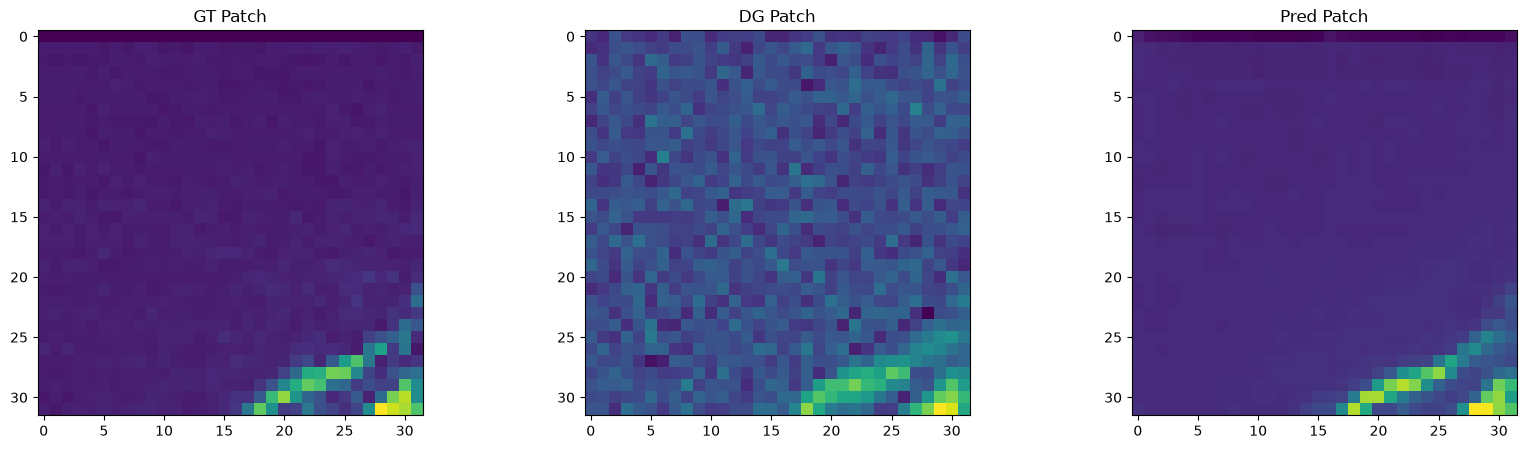

In [17]:
# Einzelne Testvisualisierung !!
# Richtige Visualisierungen alle nebeneinander & Difference Maps müssen wir weiter unten noch machen !

# Hole erstes Bild und Visualisiere
first_coords = coords[0]
Volume_Idx, Timestep, X_Start, X_End, Y_Start, Y_End, Z_Start, Z_End = first_coords

volume_pred = predictions[Volume_Idx]

print("Volume Pred shape:", volume_pred.shape)

image_pred = volume_pred[X_Start:X_End, Y_Start:Y_End, 0, Timestep]

plt.figure(figsize=(20,5))


plt.subplot(1,3,1)
plt.imshow(image_gt)
plt.title("GT Patch")

plt.subplot(1,3,2)
plt.imshow(image_dg)
plt.title("DG Patch")


plt.subplot(1,3,3)
plt.imshow(image_pred)
plt.title("Pred Patch")
plt.show()


# TODO Erweitern auf gesamtes Bild anstatt nur Patch - oder unten nach NLM


### Non-Local-Means filter (NLM)

In [24]:
import time
import numpy as np
from tqdm import tqdm
from skimage.restoration import denoise_nl_means, estimate_sigma


def apply_nlm_to_predictions(predictions):
    """
    Wendet Non-Local Means auf alle rekonstruierten Prediction-Volumes an.

    Args:
        predictions: Liste von rekonstruierten 4D Volumes
                     Shape: (X, Y, Z, T)

    Returns:
        nlm_predictions: Liste gefilterter 4D Volumes
    """

    nlm_predictions = []

    total_start = time.time()

    for volume_idx, volume in enumerate(predictions):

        print(f"\n{'='*60}")
        print(f"Starte Volume {volume_idx + 1}/{len(predictions)}")
        print(f"Shape: {tuple(volume.shape)}")
        print(f"{'='*60}")

        volume_start = time.time()

        # Tensor -> NumPy nur EINMAL
        if hasattr(volume, "numpy"):
            volume_np = volume.numpy()
        else:
            volume_np = volume

        filtered_volume = np.zeros_like(volume_np, dtype=np.float32)

        timesteps = volume_np.shape[3]

        for t in tqdm(range(timesteps),
                      desc=f"Volume {volume_idx + 1}",
                      unit="Bild"):

            print(f"\n--> Starte Bild {t+1}/{timesteps}", flush=True)

            image_start = time.time()

            img_3d = volume_np[:, :, :, t]

            sigma_est = np.mean(
                estimate_sigma(
                    img_3d,
                    channel_axis=None
                )
            )

            print(f"    Sigma geschätzt: {sigma_est:.6f}", flush=True)

            filtered = denoise_nl_means(
                img_3d,
                h=2 * sigma_est,
                fast_mode=True,
                patch_size=3,
                patch_distance=2,
                channel_axis=None
            )

            filtered_volume[:, :, :, t] = filtered.astype(np.float32)

            elapsed = time.time() - image_start

            print(
                f"✓ Bild {t+1}/{timesteps} abgeschlossen "
                f"({elapsed:.2f} Sekunden)",
                flush=True
            )

        volume_time = time.time() - volume_start

        print(f"\n Volume {volume_idx + 1} abgeschlossen")
        print(f"Benötigte Zeit: {volume_time/60:.2f} Minuten")

        nlm_predictions.append(filtered_volume)

    total_time = time.time() - total_start

    print(f"\n{'='*60}")
    print("Non-Local Means vollständig abgeschlossen")
    print(f"Gesamtzeit: {total_time/60:.2f} Minuten")
    print(f"{'='*60}")

    return nlm_predictions

In [25]:
nlm_predictions = apply_nlm_to_predictions(predictions)

print("\nNLM abgeschlossen.")

if len(nlm_predictions) > 0:
    print("Shape des ersten Volumes:", nlm_predictions[0].shape)

utils.show_ram_usage()


Starte Volume 1/1
Shape: (128, 128, 93, 219)


Volume 1:   0%|          | 0/219 [00:00<?, ?Bild/s]


--> Starte Bild 1/219
    Sigma geschätzt: 58.305596
✓ Bild 1/219 abgeschlossen (1.75 Sekunden)


Volume 1:   0%|          | 1/219 [00:01<06:22,  1.76s/Bild]


--> Starte Bild 2/219
    Sigma geschätzt: 57.076521
✓ Bild 2/219 abgeschlossen (1.41 Sekunden)


...


--> Starte Bild 219/219
    Sigma geschätzt: 56.174700
✓ Bild 219/219 abgeschlossen (1.37 Sekunden)


Volume 1: 100%|██████████| 219/219 [05:06<00:00,  1.40s/Bild]


 Volume 1 abgeschlossen
Benötigte Zeit: 5.11 Minuten

Non-Local Means vollständig abgeschlossen
Gesamtzeit: 5.11 Minuten

NLM abgeschlossen.
Shape des ersten Volumes: (128, 128, 93, 219)

                                              RAM-NUTZUNG: Speicherstatus                                               
Zeitstempel: 2026-06-19 14:51:12
------------------------------------------------------------------------------------------------------------------------
System-Prozess-Speicher (RSS): 7431.05 MiB
PyTorch CPU-Speicher: 2.99 MiB
PyTorch GPU-Speicher: 2.99 MiB
Python-Objekte (tracemalloc): 1276.89 MiB
PyTorch-Tensoren: 1278.95 MiB (95 Tensoren)
GESAMT (RSS): 7431.05 MiB
------------------------------------------------------------------------------------------------------------------------



/home/schmitt/.venv/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


{'timestamp': '2026-06-19 14:51:12',
 'rss_mb': 7431.05078125,
 'cpu_mem_mb': 2.99072265625,
 'gpu_mem_mb': 2.99072265625,
 'py_mem_mb': 1276.891074180603,
 'tensor_mem_mb': 1278.9522171020508,
 'tensor_count': 95}

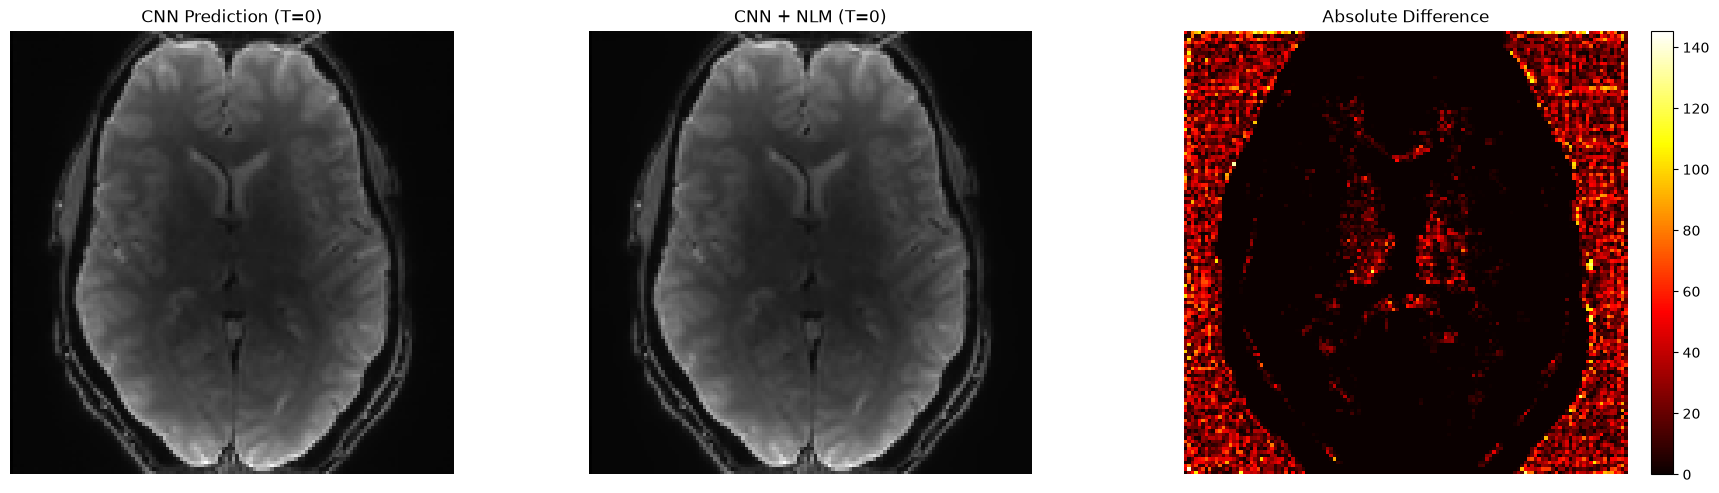

In [23]:
import matplotlib.pyplot as plt
import numpy as np

volume_idx = 0
timestep = 0
z_slice = predictions[0].shape[2] // 2

pred_img = predictions[volume_idx][:, :, z_slice, timestep].numpy()
nlm_img = nlm_predictions[volume_idx][:, :, z_slice, timestep]

difference = np.abs(pred_img - nlm_img)

vmin = min(pred_img.min(), nlm_img.min())
vmax = max(pred_img.max(), nlm_img.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CNN Prediction
axes[0].imshow(
    pred_img.T,
    cmap="gray",
    origin="lower",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("CNN Prediction (T=0)")
axes[0].axis("off")

# CNN + NLM
axes[1].imshow(
    nlm_img.T,
    cmap="gray",
    origin="lower",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("CNN + NLM (T=0)")
axes[1].axis("off")

# Absolute Difference
im = axes[2].imshow(
    difference.T,
    cmap="hot",
    origin="lower"
)
axes[2].set_title("Absolute Difference")
axes[2].axis("off")

# Colorbar nur für die Differenz
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Evaluationsmetriken

### PSNR - Peak Signal Noise Ratio

In [ ]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio

def compute_psnr_volumes(gt_volumes, pred_volumes):
    psnr_list = []

    for i, (gt, pred) in enumerate(zip(gt_volumes, pred_volumes)):

        # sicherstellen: numpy
        gt = np.asarray(gt, dtype=np.float32)
        pred = np.asarray(pred, dtype=np.float32)

        # Shape check
        if gt.shape != pred.shape:
            raise ValueError(f"Shape mismatch at volume {i}: {gt.shape} vs {pred.shape}")

        # PSNR über komplettes 4D Volume
        psnr = peak_signal_noise_ratio(
            gt,
            pred,
            data_range=gt.max() - gt.min()
        )

        psnr_list.append(psnr)
        print(f"Volume {i}: PSNR = {psnr:.4f} dB")

    mean_psnr = np.mean(psnr_list)

    print("\n====================")
    print(f"Mean PSNR: {mean_psnr:.4f} dB")
    print("====================")

    return mean_psnr, psnr_list

In [ ]:
#Ground Truth vs CNN Predictions only
mean_psnr_pred, psnr_pred_list = compute_psnr_volumes(gt, predictions)

#Ground Truth vs Degraded
mean_psnr_dg, psnr_dg_list = compute_psnr_volumes(gt, degraded)

#Ground Truth vs CNN Predictions + NLM Filter
#mean_psnr_nlm, psnr_nlm_list = compute_psnr_volumes(gt, nlm_predictions)


# Interpretation: Je höher der PSNR desto besser

Volume 0: PSNR = 39.2760 dB

Mean PSNR: 39.2760 dB
Volume 0: PSNR = 32.6260 dB

Mean PSNR: 32.6260 dB


### SSIM - Structural Similarity Index

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def compute_ssim_volumes(gt_volumes, pred_volumes):
    ssim_list = []

    for i, (gt, pred) in enumerate(zip(gt_volumes, pred_volumes)):

        gt = np.asarray(gt, dtype=np.float32)
        pred = np.asarray(pred, dtype=np.float32)

        # SSIM braucht 2D oder 3D → wir mitteln über Zeit
        t_steps = gt.shape[3]

        ssim_t = []

        for t in range(t_steps):
            s = ssim(
                gt[:, :, :, t],
                pred[:, :, :, t],
                data_range=gt.max() - gt.min()
            )
            ssim_t.append(s)

        mean_ssim = np.mean(ssim_t)
        ssim_list.append(mean_ssim)

        print(f"Volume {i}: SSIM = {mean_ssim:.4f}")

    print("Mean SSIM:", np.mean(ssim_list))
    return np.mean(ssim_list), ssim_list

In [ ]:
# Ground Truth vs CNN Predictions only
mean_ssim_pred, ssim_pred_list = compute_ssim_volumes(gt, predictions)

#Ground Truth vs Degraded
mean_ssim_dg, ssim_dg_list = compute_ssim_volumes(gt, degraded)

# Ground Truth vs CNN Predictions + NLM Filter
# mean_ssim_nlm, ssim_nlm_list = compute_ssim_volumes(gt, nlm_predictions)


# Interpretation SSIM:
# misst Strukturähnlichkeit statt nur Pixelfehler
# Wertebereich: SSIM ∈ [0, 1]; SSIM = 1: perfekte Übereinstimmung

Volume 0: SSIM = 0.9658
Mean SSIM: 0.9658101284156364
Volume 0: SSIM = 0.8322
Mean SSIM: 0.8322033635274272


### Pearson Correlation

In [ ]:
from scipy.stats import pearsonr

def compute_pearson(gt_volumes, pred_volumes):
    corr_list = []

    for gt, pred in zip(gt_volumes, pred_volumes):

        gt = np.asarray(gt, dtype=np.float32).flatten()
        pred = np.asarray(pred, dtype=np.float32).flatten()

        corr, _ = pearsonr(gt, pred)

        corr_list.append(corr)
        print("Volume correlation:", corr)

    print("Mean Pearson:", np.mean(corr_list))
    return np.mean(corr_list), corr_list

In [ ]:
# Ground Truth vs CNN Predictions only
mean_pearson_pred, pearson_pred_list = compute_pearson(gt, predictions)

#Ground Truth vs Degraded
mean_pearson_dg, pearson_dg_list = compute_pearson(gt, degraded)

# Ground Truth vs CNN Predictions + NLM Filter
# mean_pearson_nlm, pearson_nlm_list = compute_pearson(gt, nlm_predictions)


# Interpretation Pearson Correlation: 
# misst funktionale Ähnlichkeit (sehr wichtig bei Gehirndaten)
# Wertebereich: r ∈ [-1, 1]; r = 1: perfekte lineare Übereinstimmung

Volume correlation: 1.0
Mean Pearson: 1.0
Volume correlation: 0.9681424
Mean Pearson: 0.9681424


In [ ]:
#weitere Metriken...?

## Visualisierungen

siehe data prep: noise-only differences, resolution-only differences (difference map)

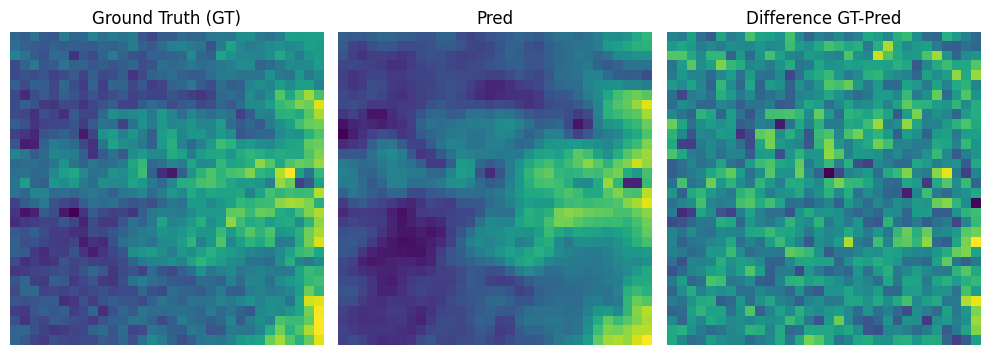

In [ ]:
# GT vs. Prediction + Difference Map (Prediction, GT)
# noise only


# TODO Erweiterung auf ganzes Bild
# TODO Skala für Difference Map


dg_batch0, gt_batch0, coords_of_patch, _, _ = next(iter(train_dataloader))
dg_batch0 = dg_batch0.to(device)

gt_batch0 = gt_batch0[0, 0, :, :, 0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(gt_batch0)
plt.title("Ground Truth (GT)")
plt.axis('off')

pred_dg = model(dg_batch0).detach().cpu()

pred_dg = pred_dg[0, 0, :, :, 0]
plt.subplot(1, 3, 2)
plt.imshow(pred_dg)
plt.title("Pred")
plt.axis('off')


difference_map = gt_batch0 - pred_dg
plt.subplot(1, 3, 3)
plt.imshow(difference_map)
plt.title("Difference GT-Pred")
plt.axis('off')


plt.tight_layout()
plt.show()
